# <center> Estimating the denisty of the tom positive and negative cells

Run this notebook after finishing `Explore_Notebook/1.explore_datasets/2.check_HSPC_atlas_tom.ipynb`

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

import PINN
from PINN import pl, tl, reader

In [6]:
os.chdir("/home/wergillius/Project/PINN_dynamics")

In [29]:
tompos = sc.read_h5ad("data/tom_pos.h5ad")
tomneg = sc.read_h5ad("data/tom_neg.h5ad")

In [42]:
ad = sc.read_h5ad("data/combined_filt.h5ad")
young_mouse_cbs = pd.read_table('data/continurous_young_mouse_cbs.txt')['cellbarcode'].values.tolist()
ad = ad[young_mouse_cbs].copy()

# compute density

In [45]:
cellstate = ad.obsm['DM_EigenVectors'].copy()

In [46]:
ub_pos_ls, den_pos_fn = tl.compute_highdim_density(tompos, timepoint_key='timepoint_tx_days', cellstate=cellstate)

In [48]:
ub_pos_ls = np.stack(ub_pos_ls)

prediction of shape (9, 112003)
prediction ranging between [0. 0. 0. 0. 0. 0. 0. 0. 0.] [4.46354656e+107 1.01737185e+099 3.05596872e+099 4.08358172e+094
 1.31424568e+093 4.51705222e+095 1.80349111e+093 2.83872700e+090
 1.32014361e+092]


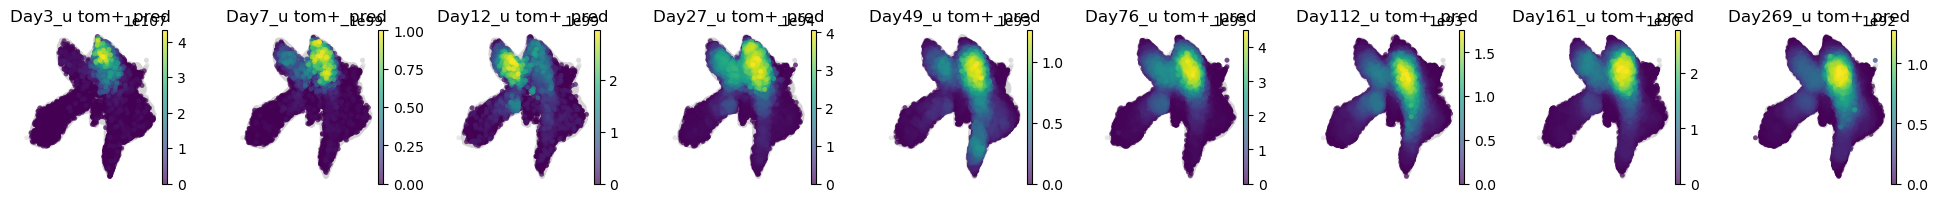

In [52]:
pl.params_in_umap(ad, ub_pos_ls, param='u tom+')

In [ ]:
ub_neg_ls, den_neg_fn = tl.compute_highdim_density(tomneg, timepoint_key='timepoint_tx_days')